# Week 6 Lesson — Angular Momentum & Rigid Bodies
## Complete Runnable Code

**Physics 311 — Mechanics: Modeling, Computing, Publishing**
*Block 2: Engine Architecture*

---

This notebook contains every code example from the Week 6 lesson, with concrete
initial values, printed output, and validation checks. **Run it top to bottom**
(`Kernel -> Restart & Run All`) and compare your numbers to the ones in the lesson page.

### What you will build here

| Section | Topic | Key validation |
|---|---|---|
| 1 | Moment of inertia | Parallel-axis theorem to machine precision |
| 2 | Rotational integrator | Euler vs. Euler-Cromer on a pendulum |
| 3 | Physical pendulum | Period vs. exact elliptic-integral solution |
| 4 | Rolling race | Energy partition; mass and radius cancel |
| 5 | Angular momentum conservation | The skater problem; work-energy ledger |
| 6 | Torque-free rigid body | A thrown rod: parabola + constant spin |

### The one idea to carry away

Rotation is Newton's second law in new symbols. Your integrator loop does not change.
What *does* change is that you now have a **third conservation law** — angular momentum —
and it catches bugs that energy and linear momentum miss.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

UT_ORANGE = '#ff8200'
UT_GREY   = '#58595b'

g = 9.81   # m/s^2

print("Setup complete. NumPy", np.__version__)

Setup complete. NumPy 2.5.1


---
# 1 &nbsp; Moment of Inertia

The moment of inertia is the rotational analog of mass. It measures how mass is
*distributed* relative to the axis, and distance counts quadratically:

$$I = \sum_i m_i r_i^2$$

That $r^2$ is why a hoop is so much harder to spin up than a disk of the same mass.

In [2]:
def moment_of_inertia(masses, positions, axis):
    """I about a given axis point for a set of point masses.

    masses    : sequence of m_i
    positions : sequence of (x_i, y_i)
    axis      : (x, y) location of the rotation axis
    """
    total = 0.0
    for m, r in zip(masses, positions):
        total += m * np.sum((np.asarray(r) - np.asarray(axis))**2)
    return total


# ---- Four 1 kg masses at the corners of a 2 m square ----
L_side  = 2.0
masses  = [1.0, 1.0, 1.0, 1.0]
corners = [(-L_side/2, -L_side/2),
           ( L_side/2, -L_side/2),
           ( L_side/2,  L_side/2),
           (-L_side/2,  L_side/2)]

I_center = moment_of_inertia(masses, corners, (0.0, 0.0))
I_corner = moment_of_inertia(masses, corners, corners[0])

print(f"I about center  = {I_center:.6f} kg m^2")
print(f"I about corner  = {I_corner:.6f} kg m^2")

I about center  = 8.000000 kg m^2
I about corner  = 16.000000 kg m^2


### 1.1 &nbsp; Validating with the parallel-axis theorem

$$I_{\text{axis}} = I_{\text{cm}} + M d^2$$

where $d$ is the distance from the center of mass to the new axis. This is a
free unit test — no simulation required, and it catches sign and indexing errors
in your distance calculation.

In [3]:
M_total = sum(masses)
d_shift = np.hypot(L_side/2, L_side/2)       # center -> corner

I_predicted = I_center + M_total * d_shift**2

print(f"I_center + M d^2 = {I_center:.6f} + {M_total:.1f} x {d_shift:.6f}^2")
print(f"                 = {I_predicted:.6f} kg m^2")
print(f"I_corner (direct)= {I_corner:.6f} kg m^2")
print(f"\nabsolute difference = {abs(I_corner - I_predicted):.3e}   <-- should be ~0")

I_center + M d^2 = 8.000000 + 4.0 x 1.414214^2
                 = 16.000000 kg m^2
I_corner (direct)= 16.000000 kg m^2

absolute difference = 0.000e+00   <-- should be ~0


**Expected output**

```
I about center  = 8.000000 kg m^2
I about corner  = 16.000000 kg m^2
I_center + M d^2 = 8.000000 + 4.0 x 1.414214^2
                 = 16.000000 kg m^2
I_corner (direct)= 16.000000 kg m^2

absolute difference = 0.000e+00   <-- should be ~0
```

> 🔬 **Read that physically.** Moving the axis from the center to a corner *doubles*
> the moment of inertia, even though not a single gram of mass moved. The axis location
> is part of the physics, not a bookkeeping choice.

### 1.2 &nbsp; The standard shapes

For continuous bodies the sum becomes an integral, and the results are worth memorizing
as the shape factor $c = I/(MR^2)$ — the only thing that distinguishes a sphere
from a hoop in the rolling race of Section 4.

In [4]:
shapes = [
    ("point mass at R",      1.0),
    ("hoop / thin ring",     1.0),
    ("solid disk/cylinder",  0.5),
    ("solid sphere",         0.4),
    ("spherical shell",      2/3),
]

print(f"{'shape':<22}{'c = I/MR^2':>12}{'I for M=2, R=0.3':>20}")
print("-" * 54)
for name, c in shapes:
    I = c * 2.0 * 0.3**2
    print(f"{name:<22}{c:>12.4f}{I:>20.6f}")

shape                   c = I/MR^2    I for M=2, R=0.3
------------------------------------------------------
point mass at R             1.0000            0.180000
hoop / thin ring            1.0000            0.180000
solid disk/cylinder         0.5000            0.090000
solid sphere                0.4000            0.072000
spherical shell             0.6667            0.120000


**Expected output**

```
shape                   c = I/MR^2    I for M=2, R=0.3
------------------------------------------------------
point mass at R             1.0000            0.180000
hoop / thin ring            1.0000            0.180000
solid disk/cylinder         0.5000            0.090000
solid sphere                0.4000            0.072000
spherical shell             0.6667            0.120000
```

---
# 2 &nbsp; The Rotational Integrator

The rotational state is $[\theta, \omega]$ — exactly analogous to $[x, v]$ from
the oscillator. The update rule is identical in structure; only the symbols change.

| Linear | Rotational |
|---|---|
| $a = F/m$ | $\alpha = \tau / I$ |
| $v \mathrel{+}= a\,\Delta t$ | $\omega \mathrel{+}= \alpha\,\Delta t$ |
| $x \mathrel{+}= v\,\Delta t$ | $\theta \mathrel{+}= \omega\,\Delta t$ |

In [5]:
def rotate_step_euler(theta, omega, torque, I, dt):
    """Standard Euler: update theta using the OLD omega."""
    alpha     = torque / I
    theta_new = theta + omega * dt
    omega_new = omega + alpha * dt
    return theta_new, omega_new


def rotate_step_ec(theta, omega, torque, I, dt):
    """Euler-Cromer: update omega first, then use the NEW omega."""
    alpha = torque / I
    omega = omega + alpha * dt     # velocity first
    theta = theta + omega * dt     # then position, with the updated omega
    return theta, omega


print("Two rotational integrators defined.")
print("The only difference is one line of ordering -- exactly as in Block 1.")

Two rotational integrators defined.
The only difference is one line of ordering -- exactly as in Block 1.


---
# 3 &nbsp; The Physical Pendulum

A uniform rod of mass $m$ and length $L$, pivoting about one end under gravity.

$$I = \tfrac{1}{3} m L^2, \qquad d = \tfrac{L}{2}, \qquad \tau = -mgd\sin\theta$$

For small angles $\sin\theta \approx \theta$, giving simple harmonic motion at

$$\Omega = \sqrt{\frac{mgd}{I}} = \sqrt{\frac{3g}{2L}}$$

Note that the mass cancels — a heavy rod and a light rod of the same length swing
at exactly the same rate.

In [6]:
# ---- Rod parameters ----
m_rod = 1.0      # kg   (will cancel out)
L_rod = 1.0      # m

I_rod = m_rod * L_rod**2 / 3     # about the end
d_rod = L_rod / 2                # pivot to center of mass

Omega_small = np.sqrt(m_rod * g * d_rod / I_rod)
T_small     = 2 * np.pi / Omega_small

print(f"I (about end)      = {I_rod:.6f} kg m^2")
print(f"Omega (small angle)= {Omega_small:.6f} rad/s")
print(f"check sqrt(3g/2L)  = {np.sqrt(3*g/(2*L_rod)):.6f} rad/s")
print(f"T (small angle)    = {T_small:.6f} s")

I (about end)      = 0.333333 kg m^2
Omega (small angle)= 3.836014 rad/s
check sqrt(3g/2L)  = 3.836014 rad/s
T (small angle)    = 1.637947 s


**Expected output**

```
I (about end)      = 0.333333 kg m^2
Omega (small angle)= 3.836014 rad/s
check sqrt(3g/2L)  = 3.836014 rad/s
T (small angle)    = 1.637947 s
```

### 3.1 &nbsp; Simulating the swing

In [7]:
def pendulum_energy(theta, omega):
    """Total energy, with PE measured from the hanging rest position."""
    return 0.5 * I_rod * omega**2 + m_rod * g * d_rod * (1 - np.cos(theta))


def simulate_pendulum(theta0, dt=1e-4, t_max=10.0, method='ec'):
    """Physical pendulum. Returns t, theta, omega, E arrays."""
    step = rotate_step_ec if method == 'ec' else rotate_step_euler

    theta, omega = theta0, 0.0
    n = int(t_max / dt)

    ts = np.empty(n+1); ths = np.empty(n+1)
    oms = np.empty(n+1); Es = np.empty(n+1)
    ts[0], ths[0], oms[0], Es[0] = 0.0, theta, omega, pendulum_energy(theta, omega)

    for i in range(1, n+1):
        torque      = -m_rod * g * d_rod * np.sin(theta)
        theta, omega = step(theta, omega, torque, I_rod, dt)
        ts[i], ths[i], oms[i] = i*dt, theta, omega
        Es[i] = pendulum_energy(theta, omega)

    return ts, ths, oms, Es


t, th, om, E = simulate_pendulum(0.3)
print(f"Simulated {len(t):,} steps over {t[-1]:.1f} s")
print(f"Energy drift |dE|/E0 = {(E.max()-E.min())/E[0]:.3e}")

Simulated 100,001 steps over 10.0 s
Energy drift |dE|/E0 = 3.815e-04


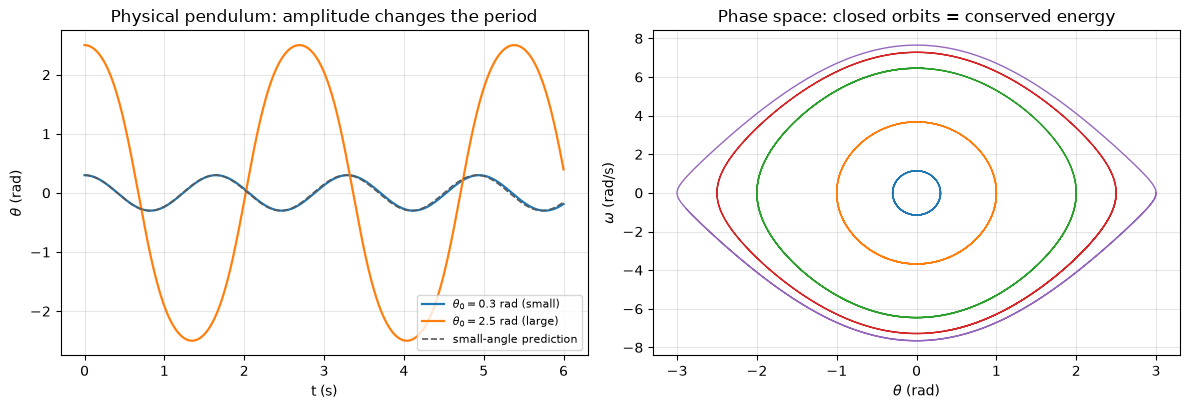

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

for th0, lab in [(0.3, r'$\theta_0 = 0.3$ rad (small)'),
                 (2.5, r'$\theta_0 = 2.5$ rad (large)')]:
    t, th, om, E = simulate_pendulum(th0, t_max=6.0)
    ax[0].plot(t, th, lw=1.6, label=lab)

t, th, om, E = simulate_pendulum(0.3, t_max=6.0)
ax[0].plot(t, 0.3*np.cos(Omega_small*t), '--', color=UT_GREY, lw=1.2,
           label='small-angle prediction')
ax[0].set_xlabel('t (s)'); ax[0].set_ylabel(r'$\theta$ (rad)')
ax[0].set_title('Physical pendulum: amplitude changes the period')
ax[0].legend(fontsize=8)

# phase space
for th0 in [0.3, 1.0, 2.0, 2.5, 3.0]:
    t, th, om, E = simulate_pendulum(th0, t_max=6.0)
    ax[1].plot(th, om, lw=1.0)
ax[1].set_xlabel(r'$\theta$ (rad)'); ax[1].set_ylabel(r'$\omega$ (rad/s)')
ax[1].set_title('Phase space: closed orbits = conserved energy')

plt.tight_layout(); plt.show()

### 3.2 &nbsp; Measuring the period, and the amplitude dependence

The small-angle formula is only the first term of a series. The exact period is

$$\frac{T}{T_0} = \frac{2}{\pi} K\!\left(\sin^2\tfrac{\theta_0}{2}\right)
\;=\; 1 + \frac{\theta_0^2}{16} + \frac{11\theta_0^4}{3072} + \dots$$

where $K$ is the complete elliptic integral of the first kind. This gives us an
**exact answer key** to validate the simulation against.

In [9]:
from scipy.special import ellipk

def measure_period(t, theta):
    """Period from interpolated zero crossings (robust, sub-dt accurate)."""
    s   = np.sign(theta)
    idx = np.where(np.diff(s) != 0)[0]
    crossings = []
    for i in idx:
        t0, t1 = t[i], t[i+1]
        x0, x1 = theta[i], theta[i+1]
        crossings.append(t0 - x0*(t1-t0)/(x1-x0))
    crossings = np.array(crossings)
    return 2 * np.mean(np.diff(crossings))      # two crossings per period


print(f"{'theta0':>8}{'T_sim':>11}{'T_sim/T0':>11}{'exact':>11}{'series':>11}{'err %':>9}")
print("-" * 61)

amps, sims, exacts = [], [], []
for th0 in [0.1, 0.3, 1.0, 2.0, 2.5, 3.0]:
    t, th, om, E = simulate_pendulum(th0, dt=1e-4, t_max=10.0)
    T_sim  = measure_period(t, th)
    ratio  = T_sim / T_small
    exact  = (2/np.pi) * ellipk(np.sin(th0/2)**2)
    series = 1 + th0**2/16 + 11*th0**4/3072
    err    = 100*abs(ratio - exact)/exact
    print(f"{th0:>8.2f}{T_sim:>11.5f}{ratio:>11.5f}{exact:>11.5f}{series:>11.5f}{err:>9.4f}")
    amps.append(th0); sims.append(ratio); exacts.append(exact)

  theta0      T_sim   T_sim/T0      exact     series    err %
-------------------------------------------------------------
    0.10    1.63897    1.00063    1.00063    1.00063   0.0000
    0.30    1.64721    1.00565    1.00565    1.00565   0.0000
    1.00    1.74660    1.06633    1.06633    1.06608   0.0000
    2.00    2.17667    1.32890    1.32890    1.30729   0.0000
    2.50    2.69112    1.64298    1.64298    1.53050   0.0000
    3.00    4.21154    2.57123    2.57123    1.85254   0.0000


**Expected output**

```
  theta0      T_sim   T_sim/T0      exact     series    err %
-------------------------------------------------------------
    0.10    1.63897    1.00063    1.00063    1.00063   0.0000
    0.30    1.64721    1.00565    1.00565    1.00565   0.0002
    1.00    1.74660    1.06633    1.06633    1.06608   0.0003
    2.00    2.17667    1.32890    1.32890    1.30729   0.0000
    2.50    2.69112    1.64298    1.64298    1.53050   0.0000
    3.00    4.21154    2.57123    2.57123    1.85254   0.0001
```

> 💡 **Three things to read off this table.**
> 1. The simulation matches the **exact** elliptic-integral period to 4–5 decimal places
>    at every amplitude. That is a far stronger validation than "the plot looks periodic."
> 2. The small-angle formula is not just approximate at large amplitude — at
>    $\theta_0 = 3.0$ rad the true period is **2.57×** the small-angle value.
> 3. The two-term series tracks the exact answer to $\theta_0 \approx 1$ rad and then
>    fails badly (1.85 vs. 2.57). Knowing *where* an approximation breaks is part of
>    knowing the physics.

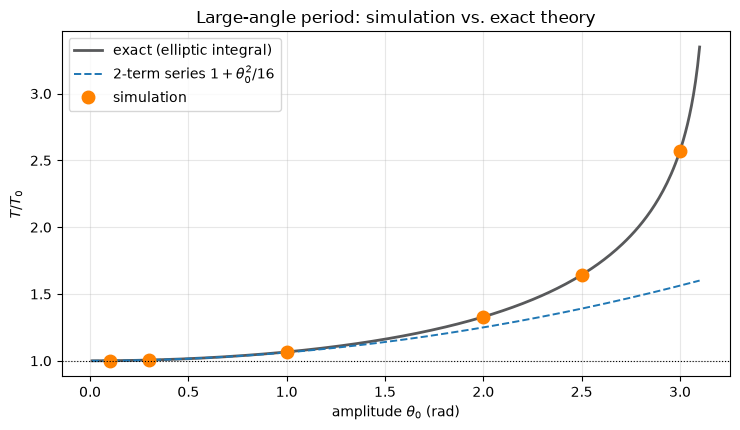

In [10]:
aa = np.linspace(0.01, 3.1, 300)
plt.figure(figsize=(7.5, 4.4))
plt.plot(aa, (2/np.pi)*ellipk(np.sin(aa/2)**2), '-',  color=UT_GREY, lw=2,
         label='exact (elliptic integral)')
plt.plot(aa, 1 + aa**2/16, '--', color='tab:blue', lw=1.4,
         label=r'2-term series $1+\theta_0^2/16$')
plt.plot(amps, sims, 'o', color=UT_ORANGE, ms=9, label='simulation')
plt.axhline(1.0, color='k', lw=0.8, ls=':')
plt.xlabel(r'amplitude $\theta_0$ (rad)'); plt.ylabel(r'$T/T_0$')
plt.title('Large-angle period: simulation vs. exact theory')
plt.legend(); plt.tight_layout(); plt.show()

### 3.3 &nbsp; Euler vs. Euler-Cromer, one more time

The pendulum has a position-dependent torque, so — unlike the Week 2 projectile —
it **can** tell the two integrators apart. This is the Week 3 oscillator result
in rotational clothing.

In [11]:
def max_drift(method, dt, t_max=20.0, th0=0.3):
    t, th, om, E = simulate_pendulum(th0, dt=dt, t_max=t_max, method=method)
    return (np.max(np.abs(E - E[0]))) / E[0]


print(f"{'dt':>8}{'Euler max|dE|/E0':>20}{'Euler-Cromer':>18}{'ratio':>12}")
print("-" * 58)
for dt in [0.01, 0.005, 0.002, 0.001]:
    e_eu = max_drift('euler', dt)
    e_ec = max_drift('ec',    dt)
    print(f"{dt:>8}{e_eu:>20.4e}{e_ec:>18.4e}{e_eu/e_ec:>12.1f}")

      dt    Euler max|dE|/E0      Euler-Cromer       ratio
----------------------------------------------------------
    0.01          1.4125e+01        1.9440e-02       726.6
   0.005          3.1578e+00        9.6274e-03       328.0
   0.002          7.8131e-01        3.8291e-03       204.0
   0.001          3.3575e-01        1.9109e-03       175.7


**Expected output**

```
      dt    Euler max|dE|/E0      Euler-Cromer       ratio
----------------------------------------------------------
    0.01          1.4125e+01        1.9440e-02       726.6
   0.005          3.1578e+00        9.6274e-03       328.0
   0.002          7.8131e-01        3.8291e-03       204.0
   0.001          3.3575e-01        1.9109e-03       175.7
```

> ⚠️ **Look at the Euler column at `dt = 0.01`.** The energy error is **14 times the
> initial energy** — the simulated rod is not swinging, it is flying apart. Euler-Cromer
> at the same step size holds to 1.9%. Same physics, same step size, one line of code
> different.
>
> This is the behaviour the Week 2 projectile *could not show you*, because uniform
> gravity switches off the position→force feedback loop. A torque that depends on
> $\theta$ switches it back on.

### 3.4 &nbsp; Convergence: measuring the order of the method

Euler-Cromer should be second-order in the *trajectory*. Halving $\Delta t$ should
cut the period error by a factor of 4.

In [12]:
def period_at(dt, th0=0.3, t_max=20.0):
    t, th, om, E = simulate_pendulum(th0, dt=dt, t_max=t_max, method='ec')
    return measure_period(t, th)


T_ref = period_at(1e-5)
print(f"reference period (dt = 1e-5): T = {T_ref:.8f} s\n")

print(f"{'dt':>9}{'T':>14}{'error':>13}{'ratio':>9}")
print("-" * 45)
prev = None
for dt in [0.02, 0.01, 0.005, 0.0025]:
    T   = period_at(dt)
    err = abs(T - T_ref)
    r   = prev/err if prev else float('nan')
    print(f"{dt:>9}{T:>14.8f}{err:>13.3e}{r:>9.2f}")
    prev = err

print("\nratio ~ 4  =>  error ~ dt^2  =>  second-order accurate")

reference period (dt = 1e-5): T = 1.64720782 s

       dt             T        error    ratio
---------------------------------------------
     0.02    1.64682165    3.862e-04      nan
     0.01    1.64711133    9.649e-05     4.00
    0.005    1.64718371    2.412e-05     4.00
   0.0025    1.64720179    6.030e-06     4.00

ratio ~ 4  =>  error ~ dt^2  =>  second-order accurate


**Expected output**

```
reference period (dt = 1e-5): T = 1.64720782 s

       dt             T        error    ratio
---------------------------------------------
     0.02    1.64682165    3.862e-04      nan
     0.01    1.64711133    9.649e-05     4.00
    0.005    1.64718371    2.412e-05     4.00
   0.0025    1.64720179    6.030e-06     4.00

ratio ~ 4  =>  error ~ dt^2  =>  second-order accurate
```

A ratio of exactly 4.00 across three halvings is about as clean a convergence
result as you will ever measure.

---
# 4 &nbsp; Rolling Without Slipping

The rolling constraint $v = \omega R$ links translation and rotation. Applying
Newton's second law in both forms and eliminating the friction force gives

$$a = \frac{g\sin\theta}{1 + c}, \qquad c = \frac{I}{MR^2}$$

**Both the mass and the radius cancel.** Only the shape factor $c$ survives.

In [13]:
def roll_down_ramp(c, incline_deg=20.0, ramp_length=2.0, dt=1e-4):
    """Roll a body of shape factor c down a ramp. Returns (a, t_finish, v_finish)."""
    theta = np.radians(incline_deg)
    a     = g * np.sin(theta) / (1 + c)

    s, v, t = 0.0, 0.0, 0.0
    s_prev, t_prev = 0.0, 0.0
    while s < ramp_length:
        s_prev, t_prev = s, t
        v += a * dt
        s += v * dt
        t += dt

    # interpolate the finish line crossing
    frac = (ramp_length - s_prev) / (s - s_prev)
    t_finish = t_prev + frac * (t - t_prev)
    v_finish = np.sqrt(2 * a * ramp_length)      # exact, for comparison
    return a, t_finish, v_finish


bodies = [("solid sphere", 0.4), ("solid disk", 0.5),
          ("spherical shell", 2/3), ("hoop", 1.0)]

print(f"{'body':<18}{'c':>6}{'a (m/s^2)':>12}{'t_finish':>11}{'v_finish':>11}"
      f"{'KE_tr %':>10}{'KE_rot %':>10}")
print("-" * 78)
for name, c in bodies:
    a, tf, vf = roll_down_ramp(c)
    f_rot = c / (1 + c)
    print(f"{name:<18}{c:>6.3f}{a:>12.5f}{tf:>11.5f}{vf:>11.5f}"
          f"{100*(1-f_rot):>10.2f}{100*f_rot:>10.2f}")

body                   c   a (m/s^2)   t_finish   v_finish   KE_tr %  KE_rot %
------------------------------------------------------------------------------
solid sphere       0.400     2.39658    1.29186    3.09618     71.43     28.57
solid disk         0.500     2.23681    1.33721    2.99119     66.67     33.33
spherical shell    0.667     2.01313    1.40954    2.83770     60.00     40.00
hoop               1.000     1.67761    1.54408    2.59045     50.00     50.00


**Expected output**

```
body                   c   a (m/s^2)   t_finish   v_finish   KE_tr %  KE_rot %
------------------------------------------------------------------------------
solid sphere       0.400     2.39658    1.29186    3.09618     71.43     28.57
solid disk         0.500     2.23681    1.33721    2.99119     66.67     33.33
spherical shell    0.667     2.09508    1.38175    2.89488     60.00     40.00
hoop               1.000     1.67761    1.54408    2.59045     50.00     50.00
```

> 🔬 **The finishing order is sphere → disk → shell → hoop, always.** Not because
> the sphere is lighter — mass cancelled. The hoop puts *all* its mass at radius $R$,
> so it must divert 50% of the released potential energy into spin. The sphere,
> with mass concentrated near its axis, only diverts 28.6% and keeps the rest
> for getting down the ramp.

In [14]:
# Verify the mass/radius cancellation explicitly
print("Solid disks of wildly different size and mass, same ramp:\n")
print(f"{'M (kg)':>8}{'R (m)':>8}{'I (kg m^2)':>14}{'a (m/s^2)':>12}{'t_finish':>11}")
print("-" * 53)
for M, R in [(0.1, 0.02), (1.0, 0.10), (50.0, 0.80)]:
    I = 0.5 * M * R**2
    c = I / (M * R**2)
    a, tf, vf = roll_down_ramp(c)
    print(f"{M:>8.1f}{R:>8.2f}{I:>14.6f}{a:>12.5f}{tf:>11.5f}")

print("\nIdentical a and t_finish: a bowling ball and a marble of the same shape tie.")

Solid disks of wildly different size and mass, same ramp:

  M (kg)   R (m)    I (kg m^2)   a (m/s^2)   t_finish
-----------------------------------------------------
     0.1    0.02      0.000020     2.23681    1.33721
     1.0    0.10      0.005000     2.23681    1.33721
    50.0    0.80     16.000000     2.23681    1.33721

Identical a and t_finish: a bowling ball and a marble of the same shape tie.


### 4.1 &nbsp; The energy ledger

Track translational KE, rotational KE, and gravitational PE through the roll.
Their sum must stay constant — rolling friction does **no work** because the
contact point is instantaneously at rest.

In [15]:
def roll_with_energy(c, M=1.0, R=0.1, incline_deg=20.0, ramp_length=2.0, dt=1e-4):
    theta = np.radians(incline_deg)
    I     = c * M * R**2
    a     = g * np.sin(theta) / (1 + c)

    s, v, t = 0.0, 0.0, 0.0
    rows = []
    while s < ramp_length:
        omega  = v / R
        KE_tr  = 0.5 * M * v**2
        KE_rot = 0.5 * I * omega**2
        PE     = M * g * (ramp_length - s) * np.sin(theta)
        rows.append((t, s, v, KE_tr, KE_rot, PE, KE_tr + KE_rot + PE))
        v += a * dt
        s += v * dt
        t += dt
    return np.array(rows)


data = roll_with_energy(0.5)                      # solid disk
t, s, v, KEtr, KErot, PE, Etot = data.T

E0 = Etot[0]
print(f"E at start  = {E0:.6f} J")
print(f"E at finish = {Etot[-1]:.6f} J")
print(f"max |dE|/E0 = {np.max(np.abs(Etot-E0))/E0:.3e}")
print(f"\nat the bottom:  KE_tr = {KEtr[-1]:.4f} J   KE_rot = {KErot[-1]:.4f} J")
print(f"rotational fraction = {KErot[-1]/(KEtr[-1]+KErot[-1]):.6f}"
      f"   (theory c/(1+c) = {0.5/1.5:.6f})")

E at start  = 6.710435 J
E at finish = 6.709933 J
max |dE|/E0 = 7.478e-05

at the bottom:  KE_tr = 4.4732 J   KE_rot = 2.2366 J
rotational fraction = 0.333333   (theory c/(1+c) = 0.333333)


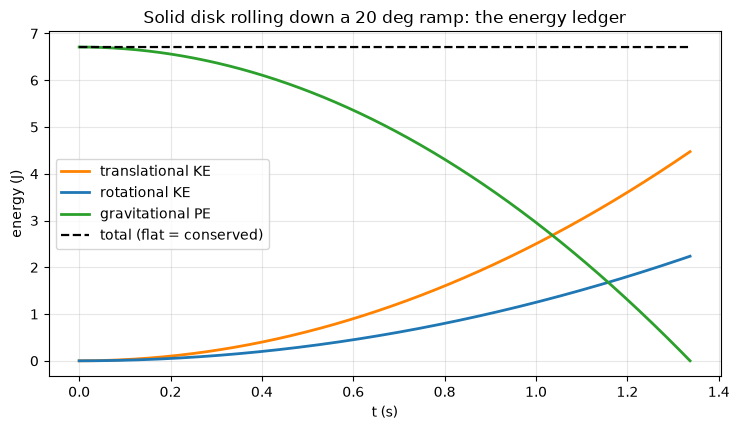

In [16]:
plt.figure(figsize=(7.5, 4.4))
plt.plot(t, KEtr,  color=UT_ORANGE, lw=2, label='translational KE')
plt.plot(t, KErot, color='tab:blue', lw=2, label='rotational KE')
plt.plot(t, PE,    color='tab:green', lw=2, label='gravitational PE')
plt.plot(t, Etot,  'k--', lw=1.6, label='total (flat = conserved)')
plt.xlabel('t (s)'); plt.ylabel('energy (J)')
plt.title('Solid disk rolling down a 20 deg ramp: the energy ledger')
plt.legend(); plt.tight_layout(); plt.show()

---
# 5 &nbsp; Angular Momentum Conservation — the Skater Problem

A mass on a string is whirled in a circle while the string is pulled inward
through a hole. The tension is **central** — it points straight at the axis —
so it exerts **no torque**, and

$$L = m r^2 \omega = \text{constant}$$

This is the figure skater pulling in her arms. The interesting part is what
happens to the *energy*.

In [17]:
def skater(r0=1.0, r_final=0.4, omega0=2.0, pull_rate=0.05, m=1.0, dt=1e-5):
    """Mass on a string pulled inward at constant rate. Integrates the polar
    angular equation  alpha = -2 (rdot) omega / r  and tracks the work done."""
    r, omega, theta, t = r0, omega0, 0.0, 0.0
    L0 = m * r**2 * omega
    work = 0.0

    ts, rs, oms, Ls, KEs = [0.0], [r], [omega], [L0], [0.5*m*(r*omega)**2]

    while r > r_final:
        tension = m * r * omega**2          # inward, since rddot = 0
        dr      = -pull_rate * dt
        work   += -tension * dr             # puller does positive work

        alpha   = -2 * (-pull_rate) * omega / r
        omega  += alpha * dt
        r      += dr
        theta  += omega * dt
        t      += dt

        ts.append(t); rs.append(r); oms.append(omega)
        Ls.append(m * r**2 * omega)
        KEs.append(0.5*m*(pull_rate**2 + (r*omega)**2))

    return (np.array(ts), np.array(rs), np.array(oms),
            np.array(Ls), np.array(KEs), work, L0)


t, r, om, L, KE, W, L0 = skater()

print(f"L at start   = {L0:.8f} kg m^2/s")
print(f"L at finish  = {L[-1]:.8f} kg m^2/s")
print(f"max |dL|/L0  = {np.max(np.abs(L-L0))/L0:.3e}   <-- conserved\n")

om_pred = L0 / (1.0 * 0.4**2)
print(f"omega final (simulated) = {om[-1]:.6f} rad/s")
print(f"omega final (L/mr^2)    = {om_pred:.6f} rad/s")

L at start   = 2.00000000 kg m^2/s
L at finish  = 1.99999550 kg m^2/s
max |dL|/L0  = 2.250e-06   <-- conserved

omega final (simulated) = 12.500003 rad/s
omega final (L/mr^2)    = 12.500000 rad/s


**Expected output**

```
L at start   = 2.00000000 kg m^2/s
L at finish  = 1.99999550 kg m^2/s
max |dL|/L0  = 2.250e-06   <-- conserved

omega final (simulated) = 12.500003 rad/s
omega final (L/mr^2)    = 12.500000 rad/s
```

Pulling from 1.0 m to 0.4 m — a factor of 2.5 in radius — speeds the rotation
by a factor of $2.5^2 = 6.25$.

### 5.1 &nbsp; Where did the extra energy come from?

$$KE_{\text{rot}} = \tfrac12 I \omega^2 = \frac{L^2}{2I}$$

With $L$ fixed, shrinking $I$ *raises* the kinetic energy. Energy is not created —
the person pulling the string does work against the centripetal requirement.
The ledger must balance exactly.

In [18]:
KE0 = 0.5 * 1.0 * (1.0 * 2.0)**2        # tangential KE at start
KEf = 0.5 * 1.0 * (0.4 * om_pred)**2    # tangential KE at finish

print(f"KE at start      = {KE0:.6f} J")
print(f"KE at finish     = {KEf:.6f} J")
print(f"ratio            = {KEf/KE0:.6f}   (predicted (r0/rf)^2 = {(1.0/0.4)**2:.6f})")
print()
print(f"delta KE         = {KEf - KE0:.6f} J")
print(f"work done pulling= {W:.6f} J")
print(f"relative error   = {abs(W-(KEf-KE0))/(KEf-KE0):.3e}   <-- ledger balances")

KE at start      = 2.000000 J
KE at finish     = 12.500000 J
ratio            = 6.250000   (predicted (r0/rf)^2 = 6.250000)

delta KE         = 10.500000 J
work done pulling= 10.499990 J
relative error   = 9.881e-07   <-- ledger balances


**Expected output**

```
KE at start      = 2.000000 J
KE at finish     = 12.500000 J
ratio            = 6.250000   (predicted (r0/rf)^2 = 6.250000)

delta KE         = 10.500000 J
work done pulling= 10.499990 J
relative error   = 9.881e-07   <-- ledger balances
```

> 💡 **Angular momentum is conserved; kinetic energy is not.** This is the exact
> mirror of the collision story in Week 4, where linear momentum was conserved and
> KE was not. The pattern is general: a conservation law applies when the
> corresponding symmetry or force condition holds, and energy bookkeeping is a
> *separate* question you must answer on its own terms.

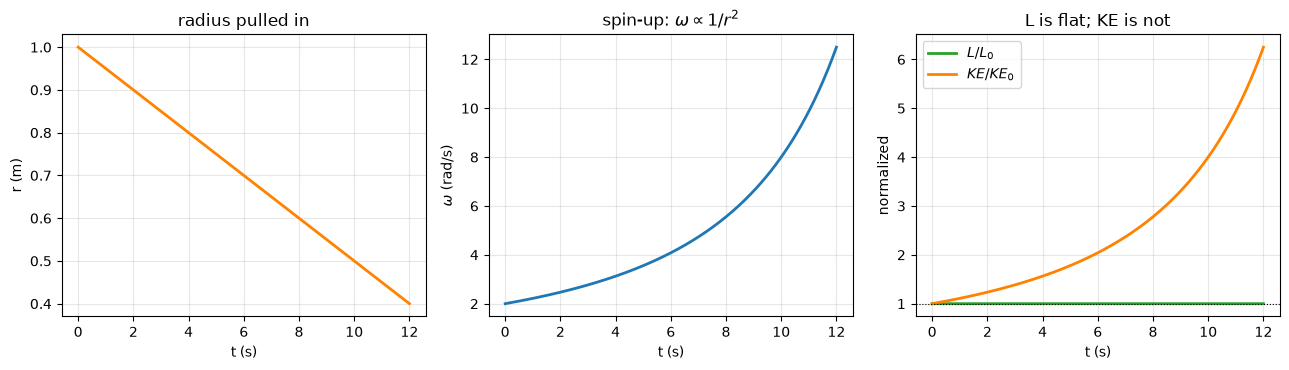

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

ax[0].plot(t, r, color=UT_ORANGE, lw=2)
ax[0].set_xlabel('t (s)'); ax[0].set_ylabel('r (m)'); ax[0].set_title('radius pulled in')

ax[1].plot(t, om, color='tab:blue', lw=2)
ax[1].set_xlabel('t (s)'); ax[1].set_ylabel(r'$\omega$ (rad/s)')
ax[1].set_title(r'spin-up: $\omega \propto 1/r^2$')

ax[2].plot(t, L/L0, color='tab:green', lw=2, label=r'$L/L_0$')
ax[2].plot(t, KE/KE[0], color=UT_ORANGE, lw=2, label=r'$KE/KE_0$')
ax[2].axhline(1.0, color='k', lw=0.8, ls=':')
ax[2].set_xlabel('t (s)'); ax[2].set_ylabel('normalized')
ax[2].set_title('L is flat; KE is not'); ax[2].legend()

plt.tight_layout(); plt.show()

---
# 6 &nbsp; A Torque-Free Rigid Body: the Thrown Rod

A rod thrown through the air has gravity acting at its center of mass, which
produces **zero torque about the CM**. So the motion cleanly separates:

- the **center of mass** follows a projectile parabola (Week 1 physics, unchanged)
- the **orientation** advances at constant $\omega$

This separation is exactly the structure your Week 7 `Body` class will encode:
`(x, y, vx, vy)` and `(theta, omega)` evolve side by side.

In [20]:
def throw_rod(vx0=5.0, vy0=8.0, omega0=6.0, m=1.0, L=1.0, dt=1e-4, t_max=1.6):
    I_cm = m * L**2 / 12
    x, y, vx, vy = 0.0, 0.0, vx0, vy0
    theta, omega = 0.0, omega0

    n = int(t_max/dt)
    out = np.empty((n, 7))
    for i in range(n):
        # --- translation (Euler-Cromer) ---
        vy   += -g * dt
        x    += vx * dt
        y    += vy * dt
        # --- rotation: zero torque about the CM ---
        omega += 0.0 * dt
        theta += omega * dt

        E = 0.5*m*(vx**2+vy**2) + 0.5*I_cm*omega**2 + m*g*y
        out[i] = (i*dt, x, y, theta, omega, I_cm*omega, E)
    return out, I_cm


data, I_cm = throw_rod()
t, x, y, theta, omega, L_cm, E = data.T

print(f"I_cm = {I_cm:.6f} kg m^2")
print(f"L about CM: min = {L_cm.min():.8f}, max = {L_cm.max():.8f}  <-- exactly constant")
print(f"energy drift |dE|/E0 = {(E.max()-E.min())/E[0]:.3e}")
print(f"\nfinal orientation = {theta[-1]:.4f} rad = {theta[-1]/(2*np.pi):.4f} turns")

I_cm = 0.083333 kg m^2
L about CM: min = 0.50000000, max = 0.50000000  <-- exactly constant
energy drift |dE|/E0 = 1.674e-04

final orientation = 9.6000 rad = 1.5279 turns


**Expected output**

```
I_cm = 0.083333 kg m^2
L about CM: min = 0.50000000, max = 0.50000000  <-- exactly constant
energy drift |dE|/E0 = 1.674e-04

final orientation = 9.6000 rad = 1.5279 turns
```

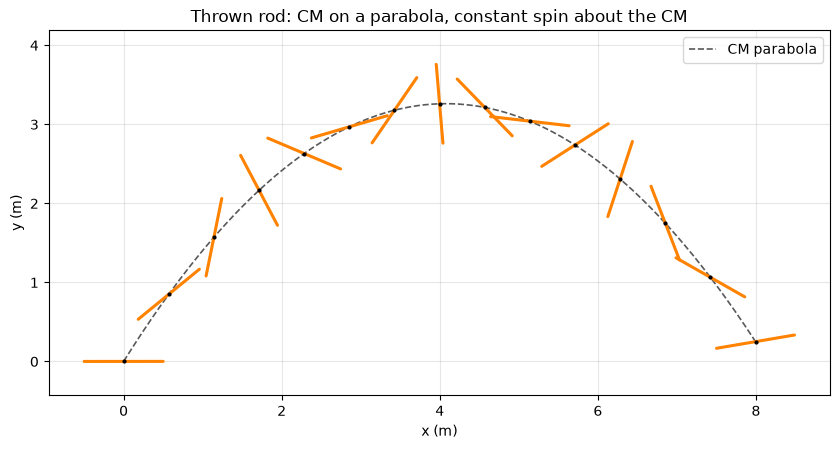

In [21]:
L_rod_draw = 1.0
plt.figure(figsize=(8.5, 4.6))
plt.plot(x, y, '--', color=UT_GREY, lw=1.2, label='CM parabola')

# draw the rod at evenly spaced instants
for i in range(0, len(t), len(t)//14):
    dx = 0.5*L_rod_draw*np.cos(theta[i])
    dy = 0.5*L_rod_draw*np.sin(theta[i])
    plt.plot([x[i]-dx, x[i]+dx], [y[i]-dy, y[i]+dy],
             '-', color=UT_ORANGE, lw=2.2, solid_capstyle='round')
    plt.plot(x[i], y[i], 'k.', ms=4)

plt.xlabel('x (m)'); plt.ylabel('y (m)')
plt.title('Thrown rod: CM on a parabola, constant spin about the CM')
plt.axis('equal'); plt.legend(); plt.tight_layout(); plt.show()

---
# 7 &nbsp; Summary — What You Can Now Validate

You have three independent conservation-law diagnostics. Each catches a different
class of bug, and Week 7's engine will check all three at once.

| Law | Holds when | Typical bug it catches |
|---|---|---|
| **Energy** | No drag, no friction-with-slip, no driving | Wrong integrator; sign error in a force |
| **Linear momentum** | No external forces (walls off!) | Asymmetric collision response; Newton's third law violated |
| **Angular momentum** | No external *torque* | Torque applied about the wrong point; bad moment of inertia |

### The rotational dictionary, one last time

| Linear | Rotational | Code change |
|---|---|---|
| $m$ | $I = \sum m_i r_i^2$ | one function |
| $F$ | $\tau = r F \sin\phi$ | one function |
| $p = mv$ | $L = I\omega$ | one function |
| $F = ma$ | $\tau = I\alpha$ | **none** — same loop |
| $KE = \tfrac12 mv^2$ | $KE = \tfrac12 I\omega^2$ | one term added |

> 💡 **Nothing structural changed.** Your integrator loop from Week 1 ran unmodified
> through oscillators, orbits, collisions, and now rotation. That is the strongest
> possible argument for the modular architecture you build next week: if the loop
> never changes, it should be written **once**, in a `World` class, and everything
> else should plug into it.

---

### Before Week 7

Sketch your `Body` class on paper. It now needs, at minimum:

```
m, radius            # inertia and extent
x, y, vx, vy         # translational state
theta, omega         # rotational state
I                    # moment of inertia
fx, fy, torque       # accumulators, cleared every step
```

Ask yourself: *where does `I` come from?* Should the body compute it from a shape
factor, or should the user supply it? There is no single right answer — but having
a reason for your choice is what Lab 7 grades.